In [2]:
from datasets import replay_to_dataframe, _normalise_paths, replay_to_filtered_dataframe
import pandas as pd
df = replay_to_filtered_dataframe("/home/tts26/sonh/Orbit-Wars-RL/gnn_rl/replays/77249937.json", target_player_name="flg")

print(f"Data Shape: {df.shape}")
df.head(20)

/home/tts26/miniconda3/envs/orbit_wars/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data Shape: (0, 0)


""


In [ ]:
import gc
import shutil
import zipfile
from pathlib import Path
import pandas as pd

from datasets import replay_to_dataframe, _normalise_paths, replay_to_filtered_dataframe

# --- Cấu hình đường dẫn ---
zip_dir = Path("/home/tts26/sonh/Orbit-Wars-RL/gnn_rl/archive")  # Đường dẫn tới thư mục chứa các file .zip
output_dir = Path("player_tonyk_chunks")
output_dir.mkdir(exist_ok=True)

temp_extract_dir = Path("temp_extracted_replays")

chunk_size = 250  # số replay files mỗi chunk
chunk_buffer = []
chunk_id = 0

# Tìm tất cả các file .zip trong thư mục
zip_files = sorted(list(zip_dir.glob("*.zip")))
total_zips = len(zip_files)

print(f"Tìm thấy {total_zips} file zip cần xử lý.")

for zip_idx, zip_path in enumerate(zip_files, 1):
    print(
        f"\n================ [{zip_idx}/{total_zips}] ĐANG XỬ LÝ: {zip_path.name} ================"
    )

    # 1. Làm sạch/Tạo mới thư mục tạm để giải nén
    if temp_extract_dir.exists():
        shutil.rmtree(temp_extract_dir)
    temp_extract_dir.mkdir(exist_ok=True)

    # 2. Giải nén file ZIP vào thư mục tạm
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(temp_extract_dir)

    # 3. Lấy danh sách paths từ thư mục tạm vừa giải nén
    # (Giả định hàm _normalise_paths nhận vào đường dẫn thư mục và trả về list các file)
    paths = _normalise_paths(str(temp_extract_dir))

    for i, path in enumerate(paths):
        print(f"[{i+1}/{len(paths)}] processing {Path(path).name}")

        df = replay_to_filtered_dataframe(
            path, target_player_name="TonyK", keep_empty_turn_ratio=0.1
        )

        if df.empty:
            continue

        chunk_buffer.append(df)

        # Đủ chunk -> save
        if len(chunk_buffer) >= chunk_size:
            chunk_df = pd.concat(chunk_buffer, ignore_index=True)
            save_path = output_dir / f"chunk_{chunk_id:03d}.parquet"

            chunk_df.to_parquet(
                save_path,
                engine="pyarrow",
                compression="snappy",
                index=False,
            )

            print(f" -> Đã lưu {save_path}")

            # Clear RAM
            del chunk_df
            del chunk_buffer
            gc.collect()

            chunk_buffer = []
            chunk_id += 1

    # 4. Xóa dữ liệu vừa giải nén sau khi chạy xong file zip hiện tại
    print(f" -> Hoàn thành {zip_path.name}. Đang xóa dữ liệu tạm...")
    shutil.rmtree(temp_extract_dir, ignore_errors=True)

# --- Xử lý phần dữ liệu còn lại sau khi duyệt hết tất cả file ZIP ---
if chunk_buffer:
    print("\n================ XỬ LÝ CHUNK CUỐI CÙNG ================")
    chunk_df = pd.concat(chunk_buffer, ignore_index=True)
    save_path = output_dir / f"chunk_{chunk_id:03d}.parquet"

    chunk_df.to_parquet(
        save_path,
        engine="pyarrow",
        compression="snappy",
        index=False,
    )

    print(f"saved {save_path}")

    del chunk_df
    del chunk_buffer
    gc.collect()

print("\nHoàn thành toàn bộ tiến trình!")

/home/tts26/miniconda3/envs/orbit_wars/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tìm thấy 10 file zip cần xử lý.

================ [1/10] ĐANG XỬ LÝ: archive23-05.zip ================
[1/4740] processing 77437090.json
[2/4740] processing 77437112.json
[3/4740] processing 77437114.json
[4/4740] processing 77437118.json
[5/4740] processing 77437121.json
[6/4740] processing 77437122.json
[7/4740] processing 77437123.json
[8/4740] processing 77437124.json
[9/4740] processing 77437125.json
[10/4740] processing 77437126.json
[11/4740] processing 77437127.json
[12/4740] processing 77437128.json
[13/4740] processing 77437130.json
[14/4740] processing 77437131.json
[15/4740] processing 77437132.json
[16/4740] processing 77437133.json
[17/4740] processing 77437134.json
[18/4740] processing 77437137.json
[19/4740] processing 77437138.json
[20/4740] processing 77437139.json
[21/4740] processing 77437140.json
[22/4740] processing 77437142.json
[23/4740] processing 77437144.json
[24/4740] processing 77437145.json
[25/4740] processing 77437146.json
[26/4740] processing 77437359.j

KeyboardInterrupt: 

Loading cache from: /home/tts26/sonh/Orbit-Wars-RL/gnn_rl/player_flg_chunks/chunk_000.cache.pt...
Tổng số samples trong cache: 1855301

THỐNG KÊ CƠ BẢN
Số lượng Real Actions : 1733512 (93.44%)
Số lượng Dummy Nodes  : 121789 (6.56%)
Invalid Actions (Bị skip hoặc lỗi): 0


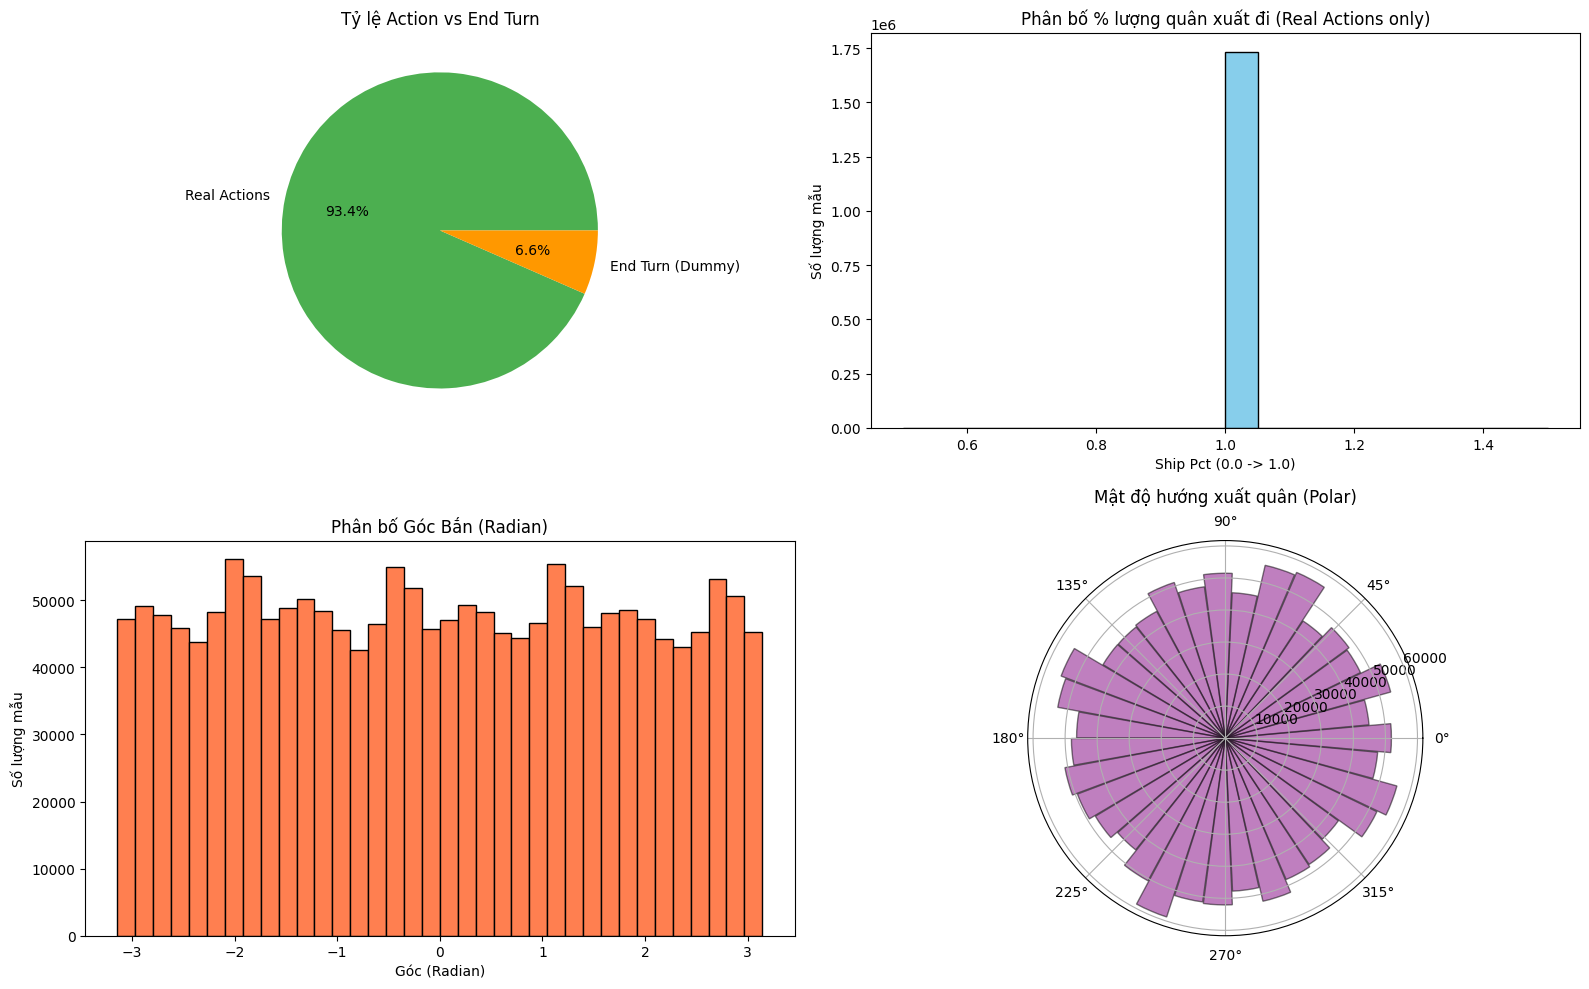

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def visualize_cache(cache_path: str):
    print(f"Loading cache from: {cache_path}...")
    try:
        samples = torch.load(cache_path)
    except Exception as e:
        print(f"Lỗi khi đọc file: {e}")
        return

    print(f"Tổng số samples trong cache: {len(samples)}")
    if len(samples) == 0:
        print("Cache rỗng!")
        return

    # 1. Bóc tách dữ liệu từ list of tuples (row_idx, labels)
    data_rows = []
    for row_idx, labels in samples:
        # labels là một dict chứa: source_id, source_idx, angle_sin, angle_cos, raw_angle, ship_pct
        row_data = {"row_idx": row_idx}
        row_data.update(labels)
        data_rows.append(row_data)

    df = pd.DataFrame(data_rows)

    # Phân loại đâu là hành động thật (Real Action) và đâu là End Turn (Dummy Node)
    # Theo logic của bạn, Dummy Node có source_id = -1
    real_actions = df[df['source_id'] != -1]
    dummy_nodes = df[df['source_id'] == -1]

    print("\n" + "="*40)
    print("THỐNG KÊ CƠ BẢN")
    print("="*40)
    print(f"Số lượng Real Actions : {len(real_actions)} ({len(real_actions)/len(df)*100:.2f}%)")
    print(f"Số lượng Dummy Nodes  : {len(dummy_nodes)} ({len(dummy_nodes)/len(df)*100:.2f}%)")
    print(f"Invalid Actions (Bị skip hoặc lỗi): {len(df[df['source_idx'] == -100])}") # -100 là IGNORE_INDEX

    # 2. Bắt đầu vẽ biểu đồ
    fig = plt.figure(figsize=(16, 10))

    # --- Biểu đồ 1: Tỷ lệ Hành động Thật vs Dummy Node ---
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.pie([len(real_actions), len(dummy_nodes)], labels=['Real Actions', 'End Turn (Dummy)'], 
            autopct='%1.1f%%', colors=['#4CAF50', '#FF9800'])
    ax1.set_title('Tỷ lệ Action vs End Turn')

    # --- Biểu đồ 2: Phân bố lượng quân (Ship Percentage) ---
    # CHÚ Ý: Chỉ lấy Real Actions để xem. Nếu đỉnh tập trung hết vào 0.0 nghĩa là lỗi trừ quân vẫn còn!
    ax2 = fig.add_subplot(2, 2, 2)
    if not real_actions.empty:
        ax2.hist(real_actions['ship_pct'], bins=20, color='skyblue', edgecolor='black')
        ax2.set_title('Phân bố % lượng quân xuất đi (Real Actions only)')
        ax2.set_xlabel('Ship Pct (0.0 -> 1.0)')
        ax2.set_ylabel('Số lượng mẫu')
    else:
        ax2.text(0.5, 0.5, 'Không có Real Action', ha='center')

    # --- Biểu đồ 3: Phân bố góc bắn (Raw Angle) ---
    ax3 = fig.add_subplot(2, 2, 3)
    if not real_actions.empty:
        ax3.hist(real_actions['raw_angle'], bins=36, color='coral', edgecolor='black')
        ax3.set_title('Phân bố Góc Bắn (Radian)')
        ax3.set_xlabel('Góc (Radian)')
        ax3.set_ylabel('Số lượng mẫu')
    else:
        ax3.text(0.5, 0.5, 'Không có Real Action', ha='center')

    # --- Biểu đồ 4: Polar Plot cho hướng bắn ---
    # Giúp bạn nhìn trực quan xem model có bị thiên vị bắn về 1 hướng nào đó trên bản đồ không
    ax4 = fig.add_subplot(2, 2, 4, projection='polar')
    if not real_actions.empty:
        angles = real_actions['raw_angle'].values
        # Đếm số lượng hành động trong mỗi bin (chia 36 hướng ~ mỗi hướng 10 độ)
        bins = np.linspace(-np.pi, np.pi, 36)
        counts, _ = np.histogram(angles, bins=bins)
        # Lấy tâm của mỗi bin để vẽ bar
        theta = (bins[:-1] + bins[1:]) / 2 
        
        ax4.bar(theta, counts, width=np.pi/18, bottom=0.0, color='purple', alpha=0.5, edgecolor='black')
        ax4.set_title('Mật độ hướng xuất quân (Polar)', va='bottom')
    else:
        ax4.text(0.5, 0.5, 'Không có Real Action', ha='center')

    plt.tight_layout()
    plt.show()

# Thay đường dẫn tới file .pt của bạn vào đây
if __name__ == "__main__":
    CACHE_FILE = "/home/tts26/sonh/Orbit-Wars-RL/gnn_rl/player_flg_chunks/chunk_000.cache.pt" 
    visualize_cache(CACHE_FILE)

In [3]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pandas as pd
import os

def log_to_csv(path, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    event_acc = EventAccumulator(path)
    event_acc.Reload()
    
    tags = event_acc.Tags()['scalars']
    
    for tag in tags:
        events = event_acc.Scalars(tag)
        # Tạo DataFrame cho từng tag riêng biệt
        df = pd.DataFrame({
            'step': [x.step for x in events],
            'value': [x.value for x in events],
            'wall_time': [x.wall_time for x in events]
        })
        
        # Lưu mỗi tag thành một file csv riêng (ví dụ: loss.csv, reward.csv)
        # Phải thay dấu "/" trong tên tag thành "_" để làm tên file
        safe_tag = tag.replace("/", "_")
        df.to_csv(os.path.join(output_dir, f"{safe_tag}.csv"), index=False)
        print(f"Đã lưu {tag} sang {safe_tag}.csv")

# Sử dụng
log_to_csv("/home/tts26/sonh/Orbit-Wars-RL/gnn_rl/runs/OrbitWars-v0__ppo__1__1780548514", "output_logs")

Đã lưu charts/episodic_return sang charts_episodic_return.csv
Đã lưu charts/episodic_length sang charts_episodic_length.csv
Đã lưu charts/learning_rate sang charts_learning_rate.csv
Đã lưu losses/value_loss sang losses_value_loss.csv
Đã lưu losses/policy_loss sang losses_policy_loss.csv
Đã lưu losses/entropy sang losses_entropy.csv
Đã lưu losses/old_approx_kl sang losses_old_approx_kl.csv
Đã lưu losses/approx_kl sang losses_approx_kl.csv
Đã lưu losses/clipfrac sang losses_clipfrac.csv
Đã lưu losses/explained_variance sang losses_explained_variance.csv
Đã lưu charts/SPS sang charts_SPS.csv
